# RAGAS black-box RAGAS filter training on Merged ASQA/MS MARCO/WikiEval dataset

Notebook này tạo feature table theo từng sample từ `labeled_merged.csv`, chỉ dùng các metric black-box của RAGAS khi **không có ground truth**, sau đó train một dãy classifier từ cơ bản đến mạnh hơn.

Output chính:
- bảng so sánh các mô hình classifier
- model tốt nhất được lưu ra disk để dùng lại
- test lại trên các tập test lẻ tẻ của từng dataset để xem hiệu quả generalization

## Imports and setup

In [18]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import ast
import importlib
import importlib.util
import sys
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
sys.path.append('..')

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)

from src.filtering.ragas import RAGAS
from src.filtering.ragas_filter_trainer import RagasFilterTrainer
from src.filtering.ragas_filter import RagasFilter
from src.evaluation import plot_evaluation_results

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


XGBOOST_AVAILABLE = importlib.util.find_spec("xgboost") is not None
XGBClassifier = importlib.import_module("xgboost").XGBClassifier if XGBOOST_AVAILABLE else None

sys.path.append('..')


pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
np.random.seed(42)

print(f"XGBOOST_AVAILABLE = {XGBOOST_AVAILABLE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
XGBOOST_AVAILABLE = True


In [19]:
DATA_PATH = Path('../data/labeled_merged.csv')
OUTPUT_DIR = Path('../results/ragas_filter')
OUTPUT_TRAIN_DIR = Path('../results/ragas_filter/merged')
MODEL_DIR = Path('../models/ragas_filter')
FEATURES_OUTPUT_DIR = Path('../results/ragas_filter/merged')
N_TIMES = 3

## Imports data and initialize evaluator

In [20]:
df = pd.read_csv(DATA_PATH)
df["label"] = df["label"].astype(int)

expected_columns = {"id", "question", "answer", "context", "label"}
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {sorted(missing_columns)}")

print(df.shape)
display(df.head())
print(df["label"].value_counts(dropna=False).sort_index())

(9806, 6)


,id,question,context,answer,label,dataset
0,asqa_0,When does the new bunk'd come out?,"- (List of Bunk'd episodes) The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28,...","The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28, 2017 and episode 42 is due ...",1,asqa
1,asqa_1,Who won the 2016 ncaa football national championship?,- (2016 College Football Playoff National Championship) The 2015 - 2016 season's ncaa national football championship...,The 2015 - 2016 season's ncaa national football championship game was played between the Clemson Tigers and the Alab...,1,asqa
2,asqa_2,When was the last time the death penalty was used in pa?,"- (QA_1) As of 2017, when was the last time the death penalty was carried out in PA? July 6, 1999.\n- (QA_2) As of 2...","The last time the death penalty was used in pa was on July 6, 1999.",1,asqa
3,asqa_3,Where will failure of the left ventricle cause increased pressure?,"- (Heart failure) ""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and theref...","""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and therefore causes increas...",1,asqa
4,asqa_4,Who won the war between ethiopia and italy?,- (Second Italo-Ethiopian War) The first war between Italy and Ethiopia took place from 1895 to 1896. This war was w...,The first war between Italy and Ethiopia took place from 1895 to 1896. This war was won by the Ethiopian army after ...,1,asqa


label
0    4903
1    4903
Name: count, dtype: int64


In [21]:
feature_dfs = []
for i in range(N_TIMES):
    feature_file = FEATURES_OUTPUT_DIR / f"merged_ragas_features_{i+1}.csv"
    if not feature_file.exists():
        raise FileNotFoundError(f"Expected feature file not found: {feature_file}")
    feature_df = pd.read_csv(feature_file)
    feature_dfs.append(feature_df)
    print(f"Loaded features from {feature_file} with shape {feature_df.shape}")

Loaded features from ../results/ragas_filter/merged/merged_ragas_features_1.csv with shape (9806, 6)
Loaded features from ../results/ragas_filter/merged/merged_ragas_features_2.csv with shape (9806, 6)
Loaded features from ../results/ragas_filter/merged/merged_ragas_features_3.csv with shape (9806, 6)


## Filter Models Training

Data splitting

In [22]:
feature_cols = [col for col in feature_df.columns if col not in {"id", "label", "dataset"}]
def data_spliting(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    X = df[feature_cols].copy()
    y = df["label"].astype(int)
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

Model training:
- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradient Boosting
- Extra Trees
- XGBoost *(if available)*


In [23]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            )),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=42,
    ),
    "extra_trees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]
    ),
}

if XGBOOST_AVAILABLE:
    models["xgboost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        missing=np.nan,
    )



Evaluate and compare models, save results to CSV

In [24]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
    }

    if hasattr(model, "predict_proba"):
        try:
            probabilities = model.predict_proba(X_test)[:, 1]
            metrics["roc_auc"] = roc_auc_score(y_test, probabilities)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, predictions

In [25]:
def test_best_model(X_test, final_predictions, feature_df):
    test_df = feature_df.loc[X_test.index].copy()
    test_df["predicted_label"] = final_predictions
    dataset_metrics = []
    for dataset_name, group in test_df.groupby("dataset"):
        acc = accuracy_score(group["label"], group["predicted_label"])
        num_sample = len(group)
        accepted = group["predicted_label"].sum()
        acceptance_rate = group["predicted_label"].mean()  # Calculate the acceptance rate
        prec = precision_score(group["label"], group["predicted_label"], zero_division=0)
        rec = recall_score(group["label"], group["predicted_label"], zero_division=0)
        f1 = f1_score(group["label"], group["predicted_label"], zero_division=0)
        roc_auc = roc_auc_score(group["label"], group["predicted_label"]) if len(group["label"].unique()) > 1 else np.nan
        
        dataset_metrics.append({
            "dataset": dataset_name,
            "num_samples": num_sample,
            "accepted": accepted,
            "acceptance_rate": acceptance_rate,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": roc_auc
        })
    # overall metrics
    overall_acc = accuracy_score(test_df["label"], test_df["predicted_label"])
    overall_prec = precision_score(test_df["label"], test_df["predicted_label"], zero_division=0)
    overall_rec = recall_score(test_df["label"], test_df["predicted_label"], zero_division=0)
    overall_f1 = f1_score(test_df["label"], test_df["predicted_label"], zero_division=0)
    overall_roc_auc = roc_auc_score(test_df["label"], test_df["predicted_label"]) if len(test_df["label"].unique()) > 1 else np.nan
    dataset_metrics.append({
        "dataset": "Overall",
        "num_samples": len(test_df),
        "accepted": test_df["predicted_label"].sum(),
        "acceptance_rate": test_df["predicted_label"].mean(),
        "accuracy": overall_acc,
        "precision": overall_prec,
        "recall": overall_rec,
        "f1": overall_f1,
        "roc_auc": overall_roc_auc
    })
    
    dataset_metrics_df = pd.DataFrame(dataset_metrics)
    display(dataset_metrics_df)
    return dataset_metrics_df

In [26]:
def filter_trainer(df: pd.DataFrame, feature_cols: list[str], test_size: float = 0.2, random_state: int = 42, models: dict[str, Pipeline] = models):
    X = df[feature_cols]
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    results = []
    trained_models = {}

    print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
    print(f"Features: {feature_cols}")
    print(f"Models: {list(models.keys())}")

    for name, model in models.items():
        metrics, _ = evaluate_classifier(model, X_train, X_test, y_train, y_test)
        results.append({"model": name, **metrics})
        trained_models[name] = model

    results_df = pd.DataFrame(results).sort_values(["accuracy", "f1"], ascending=False).reset_index(drop=True)
    display(results_df)

    best_model_name = results_df.iloc[0]['model']
    best_model = trained_models[best_model_name]
    best_model_name = f"{results_df.iloc[0]['model']}-merged-{i+1}"
    print(f"Best model: {best_model_name}")
    #save the best model
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    best_model_path = MODEL_DIR / f"{best_model_name}.joblib"
    joblib.dump(best_model, best_model_path)

    print(f"Saved best model to: {best_model_path}")

    final_predictions = best_model.predict(X_test)
    print(classification_report(y_test, final_predictions, zero_division=0))

    dataset_metrics_df = test_best_model(X_test, final_predictions, feature_df)
    
    return results_df, dataset_metrics_df, best_model_name

Run model trainer on each fold, save best model and evaluation results

In [27]:
test_size = 0.2
random_state = 42
# split to train & test sets
train_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state)
# save test df to csv
test_df.to_csv(Path('../data/labeled_merged_test.csv'), index=False)

In [28]:
results_dfs = []
metrics_dfs = []
names = []
model_paths = []
for i, feature_df in enumerate(feature_dfs):
    print(f"\n=== Fold {i+1} ===")
    results_df, dataset_metrics_df, best_model_name = filter_trainer(feature_df, feature_cols)
    results_dfs.append(results_df)
    metrics_dfs.append(dataset_metrics_df)
    names.append(best_model_name)
    model_path = MODEL_DIR / f"{best_model_name}.joblib"
    model_paths.append(model_path)


=== Fold 1 ===
Train size: 7844 | Test size: 1962
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.893476,0.942922,0.838579,0.887695,0.956225
1,xgboost,0.892966,0.922574,0.858883,0.889590,0.953304
2,hist_gradient_boosting,0.884302,0.911957,0.851777,0.880840,0.948973
3,random_forest,0.873089,0.890658,0.851777,0.870784,0.940914
4,extra_trees,0.870540,0.888417,0.848731,0.868120,0.923793
5,logistic_regression,0.818043,0.792365,0.863959,0.826615,0.902494


Best model: gradient_boosting-merged-1
Saved best model to: ../models/ragas_filter/gradient_boosting-merged-1.joblib
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       977
           1       0.94      0.84      0.89       985

    accuracy                           0.89      1962
   macro avg       0.90      0.89      0.89      1962
weighted avg       0.90      0.89      0.89      1962



,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc
0,asqa,1737,773,0.445020,0.888313,0.937904,0.832377,0.881995,0.888475
1,msmarco,207,93,0.449275,0.937198,0.989247,0.884615,0.934010,0.937453
2,wikieval,18,10,0.555556,0.888889,0.900000,0.900000,0.900000,0.887500
3,Overall,1962,876,0.446483,0.893476,0.942922,0.838579,0.887695,0.893701



=== Fold 2 ===
Train size: 7844 | Test size: 1962
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


...

,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc
0,asqa,1737,803,0.462291,0.889465,0.922790,0.850746,0.885305,0.889576
1,msmarco,207,96,0.463768,0.932367,0.968750,0.894231,0.930000,0.932552
2,wikieval,18,10,0.555556,0.888889,0.900000,0.900000,0.900000,0.887500
3,Overall,1962,909,0.463303,0.893986,0.927393,0.855838,0.890180,0.894142



=== Fold 3 ===
Train size: 7844 | Test size: 1962
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.895515,0.924837,0.861929,0.892275,0.955238
1,xgboost,0.891437,0.915948,0.862944,0.888657,0.956584
2,hist_gradient_boosting,0.884811,0.899895,0.867005,0.883144,0.953269
3,random_forest,0.876147,0.893843,0.854822,0.873897,0.943648
4,extra_trees,0.867992,0.883721,0.848731,0.865873,0.922099
5,logistic_regression,0.821101,0.795709,0.865990,0.829363,0.899756


Best model: gradient_boosting-merged-3
Saved best model to: ../models/ragas_filter/gradient_boosting-merged-3.joblib
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       977
           1       0.92      0.86      0.89       985

    accuracy                           0.90      1962
   macro avg       0.90      0.90      0.90      1962
weighted avg       0.90      0.90      0.90      1962



,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc
0,asqa,1737,811,0.466897,0.889465,0.918619,0.855339,0.885850,0.889563
1,msmarco,207,98,0.473430,0.942029,0.969388,0.913462,0.940594,0.942168
2,wikieval,18,9,0.500000,0.944444,1.000000,0.900000,0.947368,0.950000
3,Overall,1962,918,0.467890,0.895515,0.924837,0.861929,0.892275,0.895652


### Analyze feature importance of best model through folds

In [29]:
def unwrap_estimator(model):
    if hasattr(model, "named_steps"):
        # lấy step cuối trong Pipeline
        return list(model.named_steps.values())[-1]
    return model


def get_feature_importance(model, feature_cols):
    clf = unwrap_estimator(model)

    if not hasattr(clf, "feature_importances_"):
        raise ValueError(f"{type(clf)} không có feature_importances_")

    importance_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["importance_pct"] = (
        importance_df["importance"] / importance_df["importance"].sum()
    )

    return importance_df

In [30]:
# load model from disk
# get model from the files in list: names
model_files = [MODEL_DIR / f"{name}.joblib" for name in names]

models = {}
for model_file in model_files:
    if not model_file.exists():
        print(f"Model file not found: {model_file}")
        continue
    model_name = model_file.stem
    try:
        model = joblib.load(model_file)
        models[model_name] = model
        print(f"Loaded model: {model_name} from {model_file}")
    except Exception as e:
        print(f"Error loading model from {model_file}: {e}")


Loaded model: gradient_boosting-merged-1 from ../models/ragas_filter/gradient_boosting-merged-1.joblib
Loaded model: gradient_boosting-merged-2 from ../models/ragas_filter/gradient_boosting-merged-2.joblib
Loaded model: gradient_boosting-merged-3 from ../models/ragas_filter/gradient_boosting-merged-3.joblib



=== Feature Importance for gradient_boosting-merged-1 ===


,feature,importance,importance_pct
0,faithfulness,0.916224,0.916224
1,context_relevancy,0.074081,0.074081
2,answer_relevancy,0.009695,0.009695


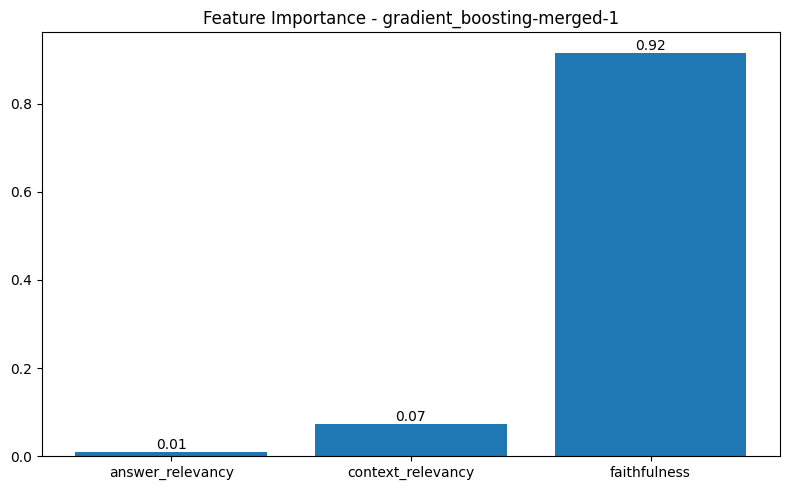


=== Feature Importance for gradient_boosting-merged-2 ===


,feature,importance,importance_pct
0,faithfulness,0.917043,0.917043
1,context_relevancy,0.074979,0.074979
2,answer_relevancy,0.007979,0.007979


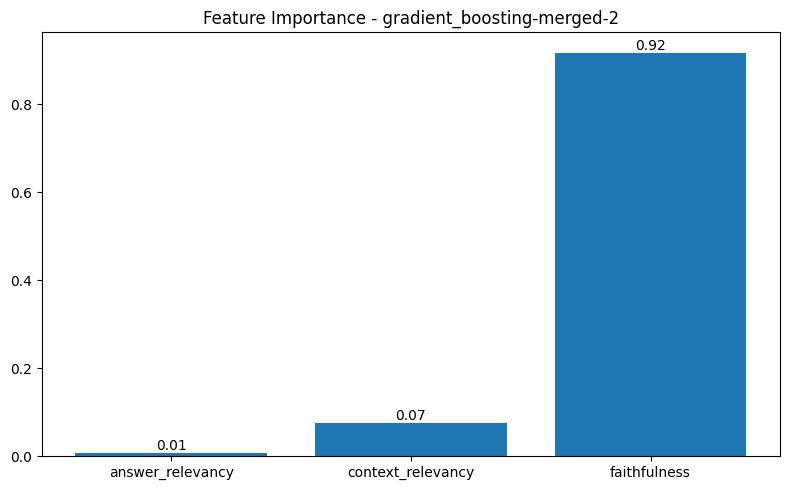


=== Feature Importance for gradient_boosting-merged-3 ===


,feature,importance,importance_pct
0,faithfulness,0.916237,0.916237
1,context_relevancy,0.075395,0.075395
2,answer_relevancy,0.008369,0.008369


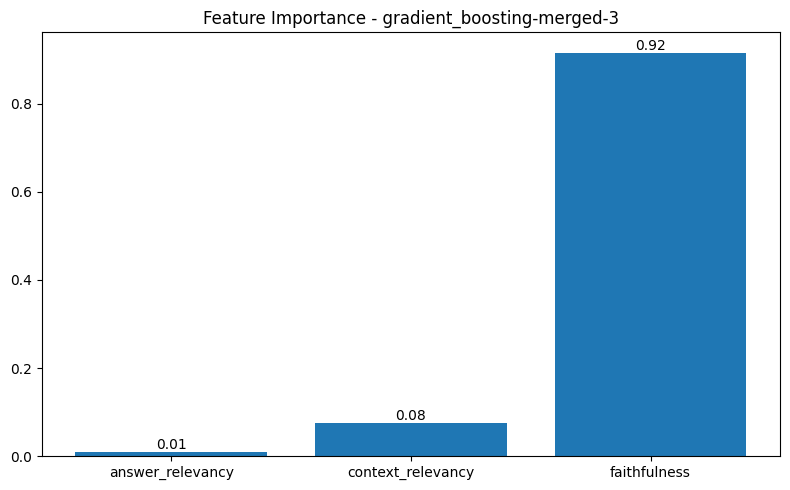

In [31]:
for model_name, model in models.items():
    print(f"\n=== Feature Importance for {model_name} ===")
    try:
        importance_df = get_feature_importance(model, feature_cols)
        display(importance_df)

        plt.figure(figsize=(8, 5))
        plt.bar(
            importance_df["feature"][::-1],
            importance_df["importance"][::-1],
        )
        importances = importance_df["importance"].values
        for i, (feature, importance) in enumerate(zip(importance_df["feature"][::-1], importance_df["importance"][::-1])):
            plt.text(i, importance, f"{importance:.2f}", ha="center", va="bottom")
        plt.title(f"Feature Importance - {model_name}")
        plt.tight_layout()
        plt.show()

    except ValueError as e:
        print(f"Cannot compute feature importance for {model_name}: {e}")

In [32]:
# average results across folds
avg_results_df = pd.concat(results_dfs).groupby("model").mean().reset_index()
display(avg_results_df.sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True))
# save average results
OUTPUT_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
avg_results_path = OUTPUT_TRAIN_DIR / "average_results.csv"
avg_results_df.to_csv(avg_results_path, index=False)
print(f"Saved average results to: {avg_results_path}")



# metrics df
dataset_name_mapping = {
    "asqa": "ASQA",
    "msmarco": "MS MARCO",
    "wikieval": "WikiEval",
}
for df in metrics_dfs:
    df["dataset"] = df["dataset"].map(dataset_name_mapping).fillna(df["dataset"])

# average metrics across folds
avg_metrics_df = pd.concat(metrics_dfs).groupby("dataset").mean().reset_index()
display(avg_metrics_df.sort_values("dataset", ascending=True).reset_index(drop=True))
avg_metrics_path = OUTPUT_DIR / "ragas_filter_merged_summary.csv"
avg_metrics_df.to_csv(avg_metrics_path, index=False)
print(f"Saved average dataset metrics to: {avg_metrics_path}")

all_metrics_df = pd.concat(metrics_dfs, ignore_index=True)

stat_df = (
    all_metrics_df
    .groupby("dataset")
    .agg({
        "accuracy": ["mean", "std"],
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "roc_auc": ["mean", "std"],
        "acceptance_rate": ["mean", "std"],
    })
)
display(stat_df)
                                                            

,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.894326,0.931717,0.852115,0.890050,0.953979
1,xgboost,0.891098,0.918608,0.859222,0.887917,0.953034
2,hist_gradient_boosting,0.884981,0.906850,0.859222,0.882358,0.948955
3,random_forest,0.875467,0.893415,0.853807,0.873162,0.941280
4,extra_trees,0.870880,0.887400,0.850761,0.868693,0.923737
5,logistic_regression,0.820591,0.795712,0.864636,0.828741,0.900744


Saved average results to: ../results/ragas_filter/merged/average_results.csv


,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc
0,ASQA,1737.0,795.666667,0.458069,0.889081,0.926438,0.846154,0.884383,0.889205
1,MS MARCO,207.0,95.666667,0.462158,0.937198,0.975795,0.897436,0.934868,0.937391
2,Overall,1962.0,901.000000,0.459225,0.894326,0.931717,0.852115,0.890050,0.894498
3,WikiEval,18.0,9.666667,0.537037,0.907407,0.933333,0.900000,0.915789,0.908333


Saved average dataset metrics to: ../results/ragas_filter/ragas_filter_merged_summary.csv


accuracy           precision              recall                  f1             roc_auc           acceptance_rate          
              mean       std      mean       std      mean       std      mean       std      mean       std            mean       std
dataset                                                                                                                               
ASQA      0.889081  0.000665  0.926438  0.010147  0.846154  0.012150  0.884383  0.002086  0.889205  0.000632        0.458069  0.011533
MS MARCO  0.937198  0.004831  0.975795  0.011654  0.897436  0.014688  0.934868  0.005349  0.937391  0.004808        0.462158  0.012158
Overall   0.894326  0.001061  0.931717  0.009788  0.852115  0.012112  0.890050  0.002293  0.894498  0.001023        0.459225  0.011271
WikiEval  0.907407  0.032075  0.933333  0.057735  0.900000  0.000000  0.915789  0.027348  0.908333  0.036084        0.537037  0.032075